In [366]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import gymnasium as gym
import matplotlib.pyplot as plt

import random
from collections import deque

import copy

import numpy as np

env = gym.make("gymnasium_2048:gymnasium_2048/TwentyFortyEight-v0", size=4, max_pow=16, render_mode = "rgb_array")

#Variables
gamma = 0.99
alpha = 0.1
epsilon = 1.0
epsilonmin = 0.05
epsilondecay = 0.999


In [367]:
def x(raw_grid):

    ret = torch.zeros((1, 16 * 16), dtype=torch.float32)

    for i in range(0,4):
        for j in range(0, 4):
            if(raw_grid[i][j] != 0):
                val = int(raw_grid[i][j])
                ret[0, 4*i + j + 16*(val - 1)] = 1

    return ret

In [368]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(256 , 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 4)
        )
    def forward(self, x):
        return self.fc(x)

In [369]:
class Replay:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    def sample(self, n):
        ret = random.sample(self.buffer, n)
        return ret
    def size(self):
        return len(self.buffer)

class DQN:
    def __init__(self):
        self.policy = Net()
        self.target = Net()
        self.target.load_state_dict(self.policy.state_dict())
        self.target.eval()
        self.optimizer = optim.Adam(self.policy.parameters(), lr=alpha)
        self.criteria = nn.MSELoss()
        self.replay = Replay(capacity=10000)
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.epsilonmin = epsilonmin
        self.epsilondecay = epsilondecay
        self.samplesize = 1000
    def decay(self):
        self.epsilon *= self.epsilondecay
        self.epsilon = max(self.epsilon, self.epsilonmin)
    def A(self, state):
        if random.random() < self.epsilon:
            return random.randrange(4)
        else:
            q = self.policy(state)
            return torch.argmax(q).item()
    def propogate(self):
        if self.replay.size() < self.samplesize:
            return None
        replay = self.replay.sample(self.samplesize)
        states, actions, rewards, next_states, dones = zip(*replay)
        states = torch.stack([torch.as_tensor(s, dtype=torch.float32) for s in states])
        actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
        next_states = torch.stack([torch.as_tensor(s, dtype=torch.float32) for s in next_states])
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)
        q = self.policy(states).squeeze(1).gather(1, actions)
        #print(q)
        with torch.no_grad():
            mq = self.target(next_states).max(1)[0].unsqueeze(1)
            q_ = rewards + (self.gamma*mq*(1-dones)) 
        loss = self.criteria(q, q_)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()   
        return loss

In [370]:
def render_board(env):

    frame = env.render()

    plt.figure(figsize=(5, 5))
    plt.imshow(frame)
    plt.axis('off')  
    plt.show()

In [371]:
def plot_results(scores, losses, window=50):
    def get_moving_average(data, w):
        return [sum(data[max(0, i-w+1):i+1]) / len(data[max(0, i-w+1):i+1]) for i in range(len(data))]
    scores_ma = get_moving_average(scores, window)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(scores, alpha=0.3, color='blue', label='Raw Score') 
    ax1.plot(scores_ma, color='darkblue', linewidth=2, label=f'{window}-Ep Moving Avg')
    ax1.set_title("Total Score per Episode")
    ax1.set_xlabel("Episode")
    ax1.set_ylabel("Score")
    ax1.legend()
    ax2.plot(losses, color='orange', alpha=0.3, label='Raw Loss')
    ax2.set_title("Average Loss per Episode")
    ax2.set_xlabel("Episode")
    ax2.set_ylabel("Loss")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

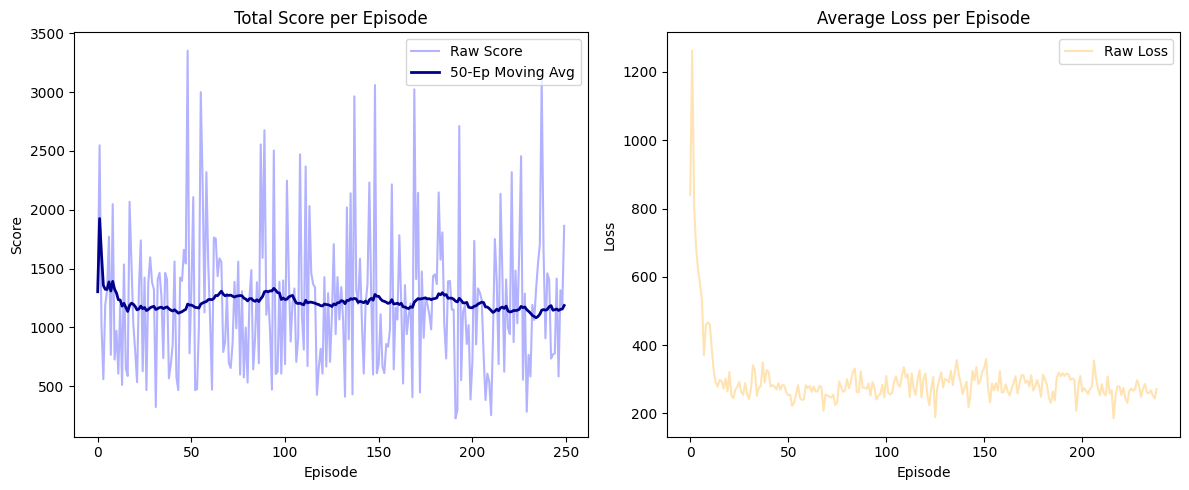

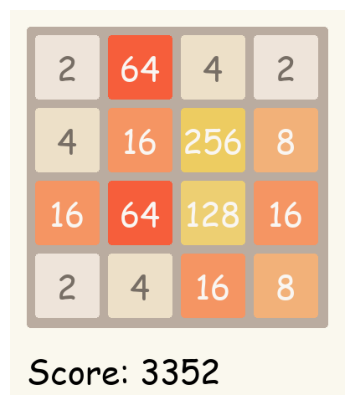

In [372]:
losses = []
scores = []
episodes = 250
freq = 500
c = 0
maxscore = 0
maxenv = None

rmap = [[1.0, 0.6, 0.6, 1.0],
        [0.6, 0.2, 0.2, 0.6],
        [0.6, 0.2, 0.2, 0.6],
        [1.0, 0.6, 0.6, 1.0]]

agent = DQN()
for episode in range(episodes):
    _, fate = env.reset()
    done = False
    s = 0
    ls = 0
    t = 0
    prev = 0
    while not done:
        grid = fate['board']
        inp = x(grid)
        a = agent.A(inp)
        next_state, reward, done, _, next_fate  = env.step(a)
        s+=reward
        reward = 0
        b = next_fate['board']
        for i in range(0,4):
            for j in range(0, 4):
                reward += rmap[i][j]*b[i][j]
        if np.array_equal(fate['board'], next_fate['board']):
            reward = -50
        agent.replay.push(x(fate['board']), a, reward - prev, x(next_fate['board']), done)
        fate = next_fate
        c += 1
        if(c%freq == 0):
            l = agent.propogate()
            if l is not None:
                ls += l
                t += 1
            agent.target.load_state_dict(agent.policy.state_dict())
        agent.decay()
        prev = reward
        
    if(s > maxscore):
        maxenv = copy.deepcopy(env)
        maxscore = s
    scores.append(s)
    if(t>0):
        losses.append((ls/t).item())
    #if(episode%349 == 0):
plot_results(scores, losses)

render_board(maxenv)
    